# One-way ANOVA: Condition A vs Condition C (pixel AOI, CTA)
Eye-tracking metrics per image. Each metric is compared between the two conditions.

In [7]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

## 1. Load and clean the data
Converts `12.3%`, `0.59s` to numbers and `N/A` to NaN (images with no fixations).

In [8]:
BASE = Path("../..")
FILE_A = BASE / "Condition A" / "pixel" / "Product.csv"
FILE_C = BASE / "Condition C" / "pixel" / "Product.csv"


def load(path):
    df = pd.read_csv(path, na_values=["N/A"])
    for col in df.columns.drop("Img"):
        if not pd.api.types.is_numeric_dtype(df[col]):
            df[col] = pd.to_numeric(df[col].astype(str).str.rstrip("%s"), errors="coerce")
    return df


a = load(FILE_A)
c = load(FILE_C)
metrics = [m for m in a.columns if m != "Img"]

print(f"Condition A: {len(a)} images | Condition C: {len(c)} images")
a.head()

Condition A: 20 images | Condition C: 20 images


,Img,VAI%,Avg. TTFF,Fix. Avg. Time Spent,Fixations,Avg. Fixation Duration,Avg. FFD,K-coefficient,Avg. Revisits
0,1,27.2,0.01,0.37,8,0.30,0.35,0.43,0.00
1,2,39.0,3.02,0.53,33,0.23,0.22,0.01,0.62
2,3,38.8,3.10,0.74,32,0.30,0.32,0.43,0.28
3,4,56.4,1.59,1.58,99,0.28,0.27,0.39,1.52
4,5,38.4,1.70,0.76,38,0.25,0.28,0.18,0.55


## 2. Run the ANOVA for every metric
NaN values are dropped per metric. Reports F, p, eta squared (effect size) and Levene's test for equal variances.

In [9]:
def one_way_anova(x, y):
    x, y = x.dropna(), y.dropna()
    f, p = stats.f_oneway(x, y)
    allv = np.concatenate([x, y])
    ss_between = len(x) * (x.mean() - allv.mean()) ** 2 + len(y) * (y.mean() - allv.mean()) ** 2
    ss_total = ((allv - allv.mean()) ** 2).sum()
    return {
        "n_A": len(x), "n_C": len(y),
        "mean_A": x.mean(), "sd_A": x.std(ddof=1),
        "mean_C": y.mean(), "sd_C": y.std(ddof=1),
        "F": f, "df": f"1, {len(x) + len(y) - 2}",
        "p": p, "eta_sq": ss_between / ss_total,
        "levene_p": stats.levene(x, y).pvalue,
    }


results = pd.DataFrame({m: one_way_anova(a[m], c[m]) for m in metrics}).T
results.index.name = "metric"
results = results.reset_index().infer_objects()
results["significant (p<.05)"] = results["p"].astype(float) < 0.05
results = results.round(4)
results

,metric,n_A,n_C,mean_A,sd_A,mean_C,sd_C,F,df,p,eta_sq,levene_p,significant (p<.05)
0,VAI%,20,20,50.5200,12.0474,50.8600,14.7140,0.0064,"1, 38",0.9367,0.0002,0.6369,False
1,Avg. TTFF,20,20,2.0695,0.6946,2.2945,0.6435,1.1293,"1, 38",0.2946,0.0289,0.7180,False
2,Fix. Avg. Time Spent,20,20,1.0330,0.4783,1.0530,0.4146,0.0200,"1, 38",0.8884,0.0005,0.5288,False
3,Fixations,20,20,68.7000,41.4337,82.0000,41.2387,1.0352,"1, 38",0.3154,0.0265,0.7677,False
4,Avg. Fixation Duration,20,20,0.2605,0.0395,0.2145,0.0233,20.1070,"1, 38",0.0001,0.3460,0.0407,True
5,Avg. FFD,20,20,0.2595,0.0543,0.2190,0.0275,8.8442,"1, 38",0.0051,0.1888,0.0253,True
6,K-coefficient,20,20,0.1145,0.2421,0.2055,0.2185,1.5570,"1, 38",0.2197,0.0394,0.4079,False
7,Avg. Revisits,20,20,1.1350,0.6720,1.3640,0.6068,1.2794,"1, 38",0.2651,0.0326,0.9159,False


## 3. Save results

In [10]:
results.to_csv("anova_A_vs_C_pixel_product_results.csv", index=False)
print("Saved anova_A_vs_C_pixel_cta_results.csv")

Saved anova_A_vs_C_pixel_cta_results.csv


## 4. Visualize
Boxplots per metric, A vs C.

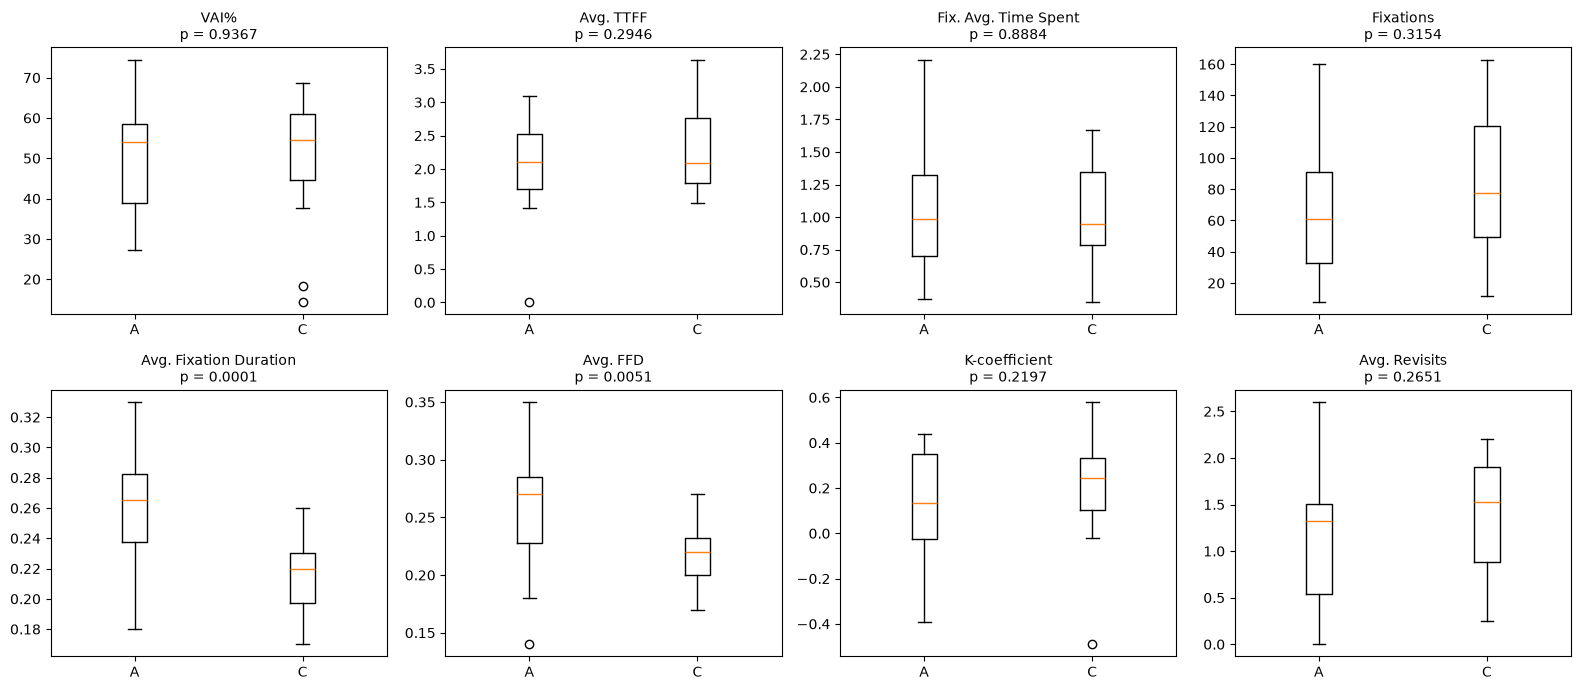

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, m in zip(axes.ravel(), metrics):
    ax.boxplot([a[m].dropna(), c[m].dropna()])
    ax.set_xticklabels(["A", "C"])
    p = results.loc[results["metric"] == m, "p"].iloc[0]
    ax.set_title(f"{m}\np = {p:.4f}", fontsize=10)
plt.tight_layout()
plt.show()